In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [8]:
data=pd.read_csv("C:\\Users\\HP\\Downloads\\Housing.csv")

In [10]:
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [22]:
#encoding columns mainroad,guestroom,basememnt,hotwaterheating,airconditioning,prefarea ,furnishingstatus
from sklearn.preprocessing import LabelEncoder
encoding_cols=['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea','furnishingstatus']

In [24]:
          for col in encoding_cols:
              data[col] = LabelEncoder().fit_transform(data[col])

In [32]:
X = data.drop('price', axis=1)
Y = data['price']


In [53]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


In [38]:
model = LinearRegression()
model.fit(X_train, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [55]:
Y_pred = model.predict(X_test)

In [51]:
new_house = pd.DataFrame([{
    'area': 8500,
    'bedrooms': 3,
    'bathrooms': 2,
    'stories': 2,
    'mainroad': 1,
    'guestroom': 0,
    'basement': 0,
    'hotwaterheating': 0,
    'airconditioning': 1,
    'parking':1,
    'prefarea': 0,
    'furnishingstatus': 2
}])

print(model.predict(new_house))

[6497539.01685541]


In [59]:
comparison = pd.DataFrame({
    'Actual Price': Y_test,
    'Predicted Price': Y_pred
})

In [67]:
comparison['Difference'] = abs(comparison['Actual Price'] - comparison['Predicted Price'])

In [69]:
print(comparison)

     Actual Price  Predicted Price    Difference
316       4060000     5.203692e+06  1.143692e+06
77        6650000     7.257004e+06  6.070040e+05
360       3710000     3.062829e+06  6.471714e+05
90        6440000     4.559592e+06  1.880408e+06
493       2800000     3.332932e+06  5.329323e+05
..            ...              ...           ...
15        9100000     4.933137e+06  4.166863e+06
357       3773000     4.377133e+06  6.041331e+05
39        7910000     7.009335e+06  9.006650e+05
54        7350000     6.351461e+06  9.985390e+05
155       5530000     6.409340e+06  8.793404e+05

[109 rows x 3 columns]


In [2]:
# as linear gives very varing output we move forward with RandomForestRegressor model
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


In [4]:
data = pd.read_csv("C:\\Users\\HP\\Downloads\\Housing.csv")


In [6]:
binary_cols = ['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']
for col in binary_cols:
    data[col] = data[col].map({'yes':1, 'no':0})

data = pd.get_dummies(data, columns=['furnishingstatus'], drop_first=True)


In [8]:
X = data.drop('price', axis=1)
y = data['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [10]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [12]:
y_pred = rf_model.predict(X_test)


In [14]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)


MAE: 1022560.0527522935
RMSE: 1401496.8425384816
R² Score: 0.6114024924156645


In [16]:
comparison = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
comparison['Difference'] = comparison['Actual'] - comparison['Predicted']
print(comparison.head(10))


      Actual   Predicted  Difference
316  4060000  5368580.00 -1308580.00
77   6650000  7270270.00  -620270.00
360  3710000  3751028.75   -41028.75
90   6440000  4493790.00  1946210.00
493  2800000  3751650.00  -951650.00
209  4900000  3440360.00  1459640.00
176  5250000  5092920.00   157080.00
249  4543000  5063730.00  -520730.00
516  2450000  2575090.00  -125090.00
426  3353000  2873276.00   479724.00


In [18]:
# Make sure feature names match training set
new_house = pd.DataFrame([{
    'area': 8500,
    'bedrooms': 3,
    'bathrooms': 2,
    'stories': 2,
    'mainroad': 1,
    'guestroom': 0,
    'basement': 0,
    'hotwaterheating': 0,
    'airconditioning': 1,
    'parking': 1,
    'prefarea': 0,
    'furnishingstatus_semi-furnished': 0,
    'furnishingstatus_unfurnished': 0
}])[X.columns]

predicted_price = rf_model.predict(new_house)
print("Predicted Price:", predicted_price[0])


Predicted Price: 7467180.0


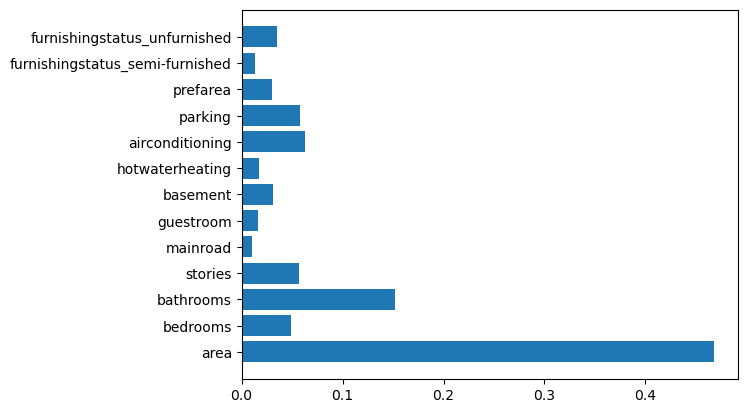

In [20]:
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
features = X.columns
plt.barh(features, importances)
plt.show()
